# diff_min/diff_max ladder sweep (`loc_algo=slice_linear`)

The `slice` location algorithm draws a plume quantile `q ~ U(diff_min, diff_max)` per
episode and initializes the agent in the `[q - 0.1, q]` quantile band of the
longitudinal puff distribution. The two thresholds therefore couple: together they
pick *which* part of the plume an episode starts in, and the pair walks as a
fixed-width window sliding from easy (near the source) to hard (plume edge). This
replaces the single `now_init_long` scalar swept in the sections above.

Bounds: `diff_min` cannot go below **0.1** (otherwise `q - 0.1` asks for a negative
quantile) and neither threshold goes above **0.6**. So the walk is `diff_min`
0.1 -> 0.5 and `diff_max` 0.2 -> 0.6, and what we sweep is the **number of lessons**
the window takes to get there.

Note when reading the results: the ladder is evenly spaced across the stage, so a
coarse ladder holds at the hardest level for a large slice of its stage (2 steps ->
half the stage) while a fine one barely holds at all (8 steps -> an eighth). The
sweep therefore trades curriculum granularity against time spent at the final
difficulty; it is not a pure granularity knob.

The ladder maths and the config validation live in `scripts/gen_cl_sweep_diff.py`, so
the ladders plotted here are the ones written to disk - they cannot drift apart. That
script can also generate the same family straight off an existing curriculum
(`--base 081626_const_jitter`) from the command line; this notebook instead builds the
skeleton from the constants below, the same way the `now_init_long` sections do.

In [ ]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO = Path("/gscratch/portia/jqhu/work/active_sensing/smartFlies")
sys.path.insert(0, str(REPO / "scripts"))
# shared with the CLI generator so plots and written configs never disagree
from gen_cl_sweep_diff import (DIFF_CEIL, DIFF_FLOOR, build_ladder, describe,
                               dump_config, make_config)

# ---- What to sweep ----
DIFF_MIN_RANGE = (0.1, 0.5)      # diff_min walks 0.1 -> 0.5
DIFF_MAX_RANGE = (0.2, 0.6)      # diff_max walks 0.2 -> 0.6, one lesson behind
diff_step_grid = [2, 3, 4, 6, 8]  # number of lessons per rotate_by stage (>= 2)

# ---- Fixed skeleton, same reference values as the now_init_long sections ----
BIRTHX_START_T, BIRTHX_END_T = 150, 200     # birthx active window
BIRTHX_HI, BIRTHX_LO = 0.7, 0.3
BIRTHX_STEPS = 5                            # held fixed: only the diff ladder is swept
CYCLE_LEN = 50                              # restart_period; also the rotate_by stage length
TOTAL_UPDATES = 200
RESTART_PERIOD = 50
HOLD_FRAC = 0.25                            # trailing hold so the agent trains at the final value

WIND_COND = {"0": 1}
ROTATE_BY = {
    "0":   [0, 180],
    "50":  [90, -90],
    "100": [0, 90, 180, -90],
}

# The diff ladder restarts inside each rotate_by stage, exactly as
# build_tc_schedule_dict lays out the slice lessons: [(stage_start, duration), ...].
# The last stage ends where the birthx tail takes over.
_stage_starts = sorted(int(t) for t in ROTATE_BY)
STAGE_LAYOUT = [(s, (_stage_starts[i + 1] if i + 1 < len(_stage_starts) else BIRTHX_START_T) - s)
                for i, s in enumerate(_stage_starts)]


def make_birthx_schedule(n_steps, mode="linear"):
    """birthx steps HI -> LO over [150, 200], reserving a trailing hold."""
    span = (BIRTHX_END_T - BIRTHX_START_T) * (1.0 - HOLD_FRAC)
    offsets = (np.linspace(0, span, n_steps, endpoint=True) if mode == "linear"
               else np.geomspace(1, span + 1, n_steps) - 1)
    vals = np.linspace(BIRTHX_HI, BIRTHX_LO, n_steps)
    return {str(int(round(BIRTHX_START_T + off))): round(float(v), 4)
            for off, v in zip(offsets, vals)}


def skeleton(dataset):
    """Everything that is *not* the diff ladder; make_config fills the rest in."""
    return {
        "birthx": make_birthx_schedule(BIRTHX_STEPS),
        "wind_cond": WIND_COND,
        f"{dataset}_rotate_by": ROTATE_BY,
        "meta": {"restart_period": RESTART_PERIOD, "total_num_updates": TOTAL_UPDATES},
    }


print("stages (start, duration):", STAGE_LAYOUT)
print("sweeping", diff_step_grid, "lessons/stage over",
      f"diff_min {DIFF_MIN_RANGE} / diff_max {DIFF_MAX_RANGE}",
      f"(allowed band {DIFF_FLOOR}~{DIFF_CEIL})")

In [ ]:
def step_trace(ts, vals, t_end):
    xs, ys = [], []
    for i, (t, v) in enumerate(zip(ts, vals)):
        nxt = ts[i + 1] if i + 1 < len(ts) else t_end
        xs.extend([t, nxt]); ys.extend([v, v])
    return xs, ys


cmap = plt.get_cmap("tab10")
colors = {n: cmap(i) for i, n in enumerate(diff_step_grid)}
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for ax, track, ls in [(axes[0], "diff_min", "-"), (axes[1], "diff_max", "--")]:
    for n in diff_step_grid:
        lo, hi = build_ladder(n, STAGE_LAYOUT, DIFF_MIN_RANGE, DIFF_MAX_RANGE)
        sched = lo if track == "diff_min" else hi
        ts = sorted(sched)
        xs, ys = step_trace(ts, [sched[t] for t in ts], BIRTHX_START_T)
        ax.plot(xs, ys, ls, color=colors[n], lw=1.6, alpha=0.9, label=f"{n} steps")
        ax.scatter(ts, [sched[t] for t in ts], s=12, color=colors[n], zorder=5)
    for s in sorted(int(t) for t in ROTATE_BY):
        ax.axvline(s, color="gray", ls=":", lw=1)
    ax.axvspan(BIRTHX_START_T, TOTAL_UPDATES, color="green", alpha=0.10)
    ax.axhspan(DIFF_FLOOR, DIFF_CEIL, color="orange", alpha=0.06)
    ax.set_title(f"{track}: restarts each rotate_by stage (dotted), "
                 f"birthx tail shaded")
    ax.set_xlabel("update step"); ax.set_ylabel(track); ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="lower right", title="# steps")

plt.tight_layout()
plt.savefig("curriculum_diff_steps.png", dpi=130)
plt.show()
print("saved curriculum_diff_steps.png")

# the coupled window, for the widest and narrowest ladders
for n in (min(diff_step_grid), max(diff_step_grid)):
    lo, _ = build_ladder(n, STAGE_LAYOUT, DIFF_MIN_RANGE, DIFF_MAX_RANGE)
    print(f"n={n}: {len(lo)} lessons total, one every "
          f"{STAGE_LAYOUT[0][1] // n} updates")

In [ ]:
# ---- Generate one config per step count, for each dataset ----
# Prefix per dataset so `--sweep_config sweep_diff_const` never mixes in the noisy
# family (or the now_init_long `sweep_const_*` configs from the sections above).
DATASETS = {
    "constant_jitterx5b5": "sweep_diff_const",
    "noisy_jitterx5b5": "sweep_diff_noisy",
}

out_dir = REPO / "tamagotchi/conf/curriculum"
out_dir.mkdir(exist_ok=True)

for dataset, prefix in DATASETS.items():
    # drop a previous run of this family so a stale step count is not swept along
    for stale in sorted(out_dir.glob(f"{prefix}_n*.json")):
        stale.unlink()
        print(f"removed  {stale.name}")

    base = skeleton(dataset)
    for n in diff_step_grid:
        # make_config validates: keys match the dataset, thresholds stay in the
        # 0.1~0.6 band, and diff_min stays strictly below diff_max
        cfg = make_config(base, dataset, STAGE_LAYOUT, n,
                          DIFF_MIN_RANGE, DIFF_MAX_RANGE,
                          base_name=f"CL_sweep.ipynb skeleton ({TOTAL_UPDATES} updates)")
        path = dump_config(cfg, out_dir / f"{prefix}_n{n:02d}.json")
        head, ladder = describe(cfg, dataset, STAGE_LAYOUT, n)
        print(f"{Path(path).name}  {head}")
        print(f"    {ladder}")

    print(f"\nsweep {dataset} with:\n"
          f"  python3 scripts/slurm-run_ckpt.py --n_seeds <N> --sweep_config {prefix} \\\n"
          f"      --sweep_outsuffix --override \"... loc_algo=slice_linear "
          f"'dataset=[{dataset}]'\"\n")

# now_init_long sweep (`loc_algo=linear_precise`) - plot

Legacy section: sweeps `birthx` steps x `now_init_long` steps. `now_init_long` is
read by the `precise` branch of `get_initial_location`. For the `slice` algorithm
(`loc_algo=slice_linear`) use the **diff_min/diff_max ladder sweep** sections below.

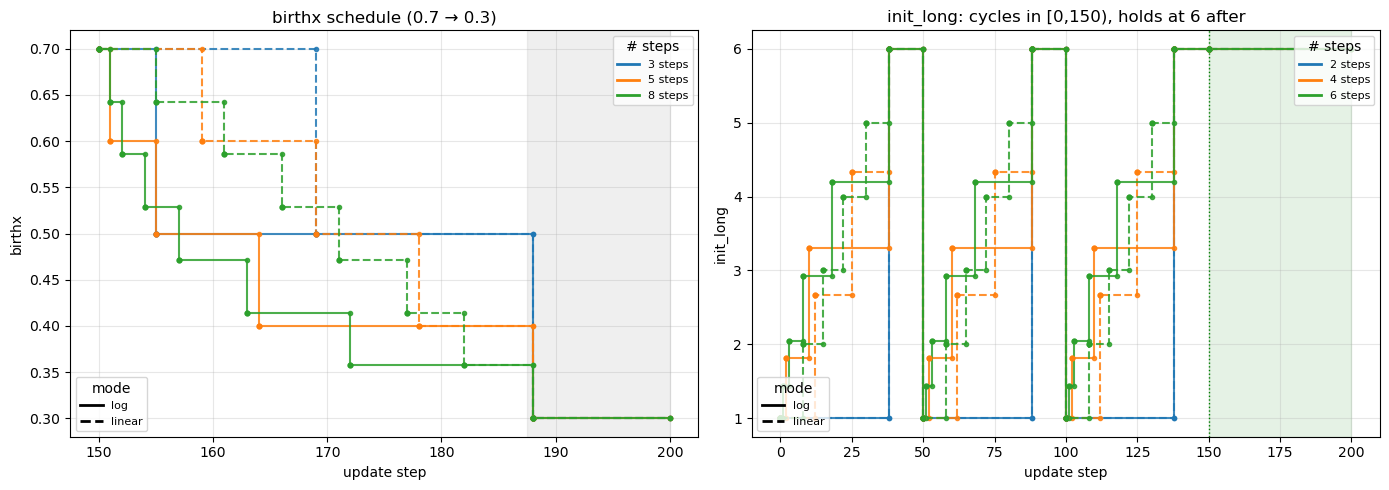

saved curriculum_step_modes.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Config constants ----
BIRTHX_START_T, BIRTHX_END_T = 150, 200
BIRTHX_HI, BIRTHX_LO = 0.7, 0.3
INIT_LONG_MIN, INIT_LONG_MAX = 1.0, 6.0
CYCLE_LEN = 50
INIT_CYCLE_END_T = 150          # cycling stops here; hold at MAX afterward
TOTAL_UPDATES = 200
HOLD_FRAC = 0.25

birthx_step_grid = [3, 5, 8]
init_step_grid = [2, 4, 6]


def _onsets(n_steps, span, mode):
    ramp_span = span * (1.0 - HOLD_FRAC)
    if mode == "linear":
        return np.linspace(0, ramp_span, n_steps, endpoint=True)
    return np.geomspace(1, ramp_span + 1, n_steps) - 1


def make_init_schedule(n_steps, mode):
    """init_long cycles (refresh every CYCLE_LEN) only during [0, INIT_CYCLE_END_T),
    then pins at MAX (6) from INIT_CYCLE_END_T to the end of training."""
    offs = _onsets(n_steps, CYCLE_LEN, mode)
    vals = (np.geomspace(INIT_LONG_MIN, INIT_LONG_MAX, n_steps) if mode == "log"
            else np.linspace(INIT_LONG_MIN, INIT_LONG_MAX, n_steps))
    sched = {}
    n_cycles = INIT_CYCLE_END_T // CYCLE_LEN
    for c in range(n_cycles):
        base = c * CYCLE_LEN
        for off, v in zip(offs, vals):
            sched[int(round(base + off))] = round(float(v), 4)
    # pin at MAX once cycling ends, and train at it for the rest of the run
    sched[INIT_CYCLE_END_T] = float(INIT_LONG_MAX)
    return sched


def step_trace(ts, vals, t_end):
    xs, ys = [], []
    for i, (t, v) in enumerate(zip(ts, vals)):
        nxt = ts[i + 1] if i + 1 < len(ts) else t_end
        xs.extend([t, nxt]); ys.extend([v, v])
    return xs, ys


MODE_STYLE = {"log": "-", "linear": "--"}
cmap = plt.get_cmap("tab10")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- birthx (unchanged) ---
ax = axes[0]
birthx_colors = {n: cmap(i) for i, n in enumerate(birthx_step_grid)}
span = BIRTHX_END_T - BIRTHX_START_T
for n in birthx_step_grid:
    c = birthx_colors[n]
    vals = np.linspace(BIRTHX_HI, BIRTHX_LO, n)
    for mode, ls in MODE_STYLE.items():
        ts = np.round(BIRTHX_START_T + _onsets(n, span, mode)).astype(int)
        xs, ys = step_trace(ts, vals, BIRTHX_END_T)
        ax.plot(xs, ys, ls, color=c, marker="o", ms=3, alpha=0.85)
        ax.scatter(ts, vals, s=12, color=c, zorder=5)
ax.axvspan(BIRTHX_START_T + span * (1 - HOLD_FRAC), BIRTHX_END_T,
           color="gray", alpha=0.12)
ax.set_title("birthx schedule (0.7 → 0.3)")
ax.set_xlabel("update step"); ax.set_ylabel("birthx"); ax.grid(alpha=0.3)

# --- init_long: full timeline now, cycles then holds at 6 ---
ax = axes[1]
init_colors = {n: cmap(i) for i, n in enumerate(init_step_grid)}
for n in init_step_grid:
    c = init_colors[n]
    for mode, ls in MODE_STYLE.items():
        sched = make_init_schedule(n, mode)
        ts = np.array(sorted(sched))
        vals = np.array([sched[t] for t in ts])
        xs, ys = step_trace(ts, vals, TOTAL_UPDATES)
        ax.plot(xs, ys, ls, color=c, marker="o", ms=3, alpha=0.85)
        ax.scatter(ts, vals, s=12, color=c, zorder=5)
ax.axvspan(INIT_CYCLE_END_T, TOTAL_UPDATES, color="green", alpha=0.10)
ax.axvline(INIT_CYCLE_END_T, color="green", ls=":", lw=1)
ax.set_title("init_long: cycles in [0,150), holds at 6 after")
ax.set_xlabel("update step"); ax.set_ylabel("init_long"); ax.grid(alpha=0.3)

from matplotlib.lines import Line2D
for ax, colors, grid in [(axes[0], birthx_colors, birthx_step_grid),
                         (axes[1], init_colors, init_step_grid)]:
    color_handles = [Line2D([0], [0], color=colors[n], lw=2, label=f"{n} steps")
                     for n in grid]
    style_handles = [Line2D([0], [0], color="k", lw=2, ls=ls, label=mode)
                     for mode, ls in MODE_STYLE.items()]
    leg1 = ax.legend(handles=color_handles, fontsize=8, loc="upper right", title="# steps")
    ax.add_artist(leg1)
    ax.legend(handles=style_handles, fontsize=8, loc="lower left", title="mode")

plt.tight_layout()
plt.savefig("curriculum_step_modes.png", dpi=130)
plt.show()
print("saved curriculum_step_modes.png")

# now_init_long sweep - gen (const)

In [5]:
import json
import numpy as np
from itertools import product
from pathlib import Path


# ---- Fixed reference values from the original curriculum ----
BIRTHX_START_T, BIRTHX_END_T = 150, 200     # birthx active window
BIRTHX_HI, BIRTHX_LO = 0.7, 0.3             # value at start -> final value

INIT_LONG_MIN, INIT_LONG_MAX = 1.0, 6.0     # init_long ramps within each cycle
CYCLE_LEN = 50                              # restart_period; FIXED
INIT_CYCLE_END_T = 150                      # cycling stops here; hold at MAX after
TOTAL_UPDATES = 200
RESTART_PERIOD = 50

HOLD_FRAC = 0.25                            # trailing hold so agent trains at final value

WIND_COND = {"0": 1}
ROTATE_BY = {
    "0":   [0, 180],
    "50":  [90, -90],
    "100": [0, 90, 180, -90],
}


def _onsets(n_steps, span, mode):
    """Onsets within the ramp portion (window minus trailing hold). Last onset
    lands at ramp_span so the final value persists through the hold interval."""
    ramp_span = span * (1.0 - HOLD_FRAC)
    if mode == "linear":
        return np.linspace(0, ramp_span, n_steps, endpoint=True)
    elif mode == "log":
        return np.geomspace(1, ramp_span + 1, n_steps) - 1
    raise ValueError(mode)


def make_birthx_schedule(n_steps, mode):
    """birthx steps HI -> LO over [150, 200], reserving a trailing hold so the
    agent trains at the final value."""
    span = BIRTHX_END_T - BIRTHX_START_T
    offsets = _onsets(n_steps, span, mode)
    vals = np.linspace(BIRTHX_HI, BIRTHX_LO, n_steps)

    sched = {}
    for off, v in zip(offsets, vals):
        sched[str(int(round(BIRTHX_START_T + off)))] = round(float(v), 4)
    return sched


def make_init_schedule(n_steps, mode):
    """init_long cycles (refresh every CYCLE_LEN) during [0, INIT_CYCLE_END_T),
    then pins at MAX (6) from INIT_CYCLE_END_T through the end of training."""
    offsets = _onsets(n_steps, CYCLE_LEN, mode)
    if mode == "linear":
        vals = np.linspace(INIT_LONG_MIN, INIT_LONG_MAX, n_steps)
    else:
        vals = np.geomspace(INIT_LONG_MIN, INIT_LONG_MAX, n_steps)

    sched = {}
    n_cycles = INIT_CYCLE_END_T // CYCLE_LEN
    for c in range(n_cycles):
        base = c * CYCLE_LEN
        for off, v in zip(offsets, vals):
            sched[str(int(round(base + off)))] = round(float(v), 4)
    # pin at MAX once cycling ends; holds flat for the rest of the run
    sched[str(INIT_CYCLE_END_T)] = float(INIT_LONG_MAX)
    return sched


def build_config(birthx_steps, birthx_mode, init_steps, init_mode):
    return {
        "birthx": make_birthx_schedule(birthx_steps, birthx_mode),
        "wind_cond": WIND_COND,
        "constant_jitterx5b5_rotate_by": ROTATE_BY,
        "constant_jitterx5b5_now_init_long": make_init_schedule(init_steps, init_mode),
        "meta": {
            "restart_period": RESTART_PERIOD,
            "total_num_updates": TOTAL_UPDATES,
        },
    }


# ---- Grid definition ----
birthx_step_grid = [3, 5, 8]
birthx_mode_grid = ["linear", "log"]
init_step_grid = [2, 4, 6]
init_step_grid = [3]
init_mode_grid = ["linear"]                 # only linear for init_long for now

out_dir = Path("/gscratch/portia/jqhu/work/active_sensing/smartFlies/tamagotchi/conf/curriculum/")
out_dir.mkdir(exist_ok=True)

count = 0
for bx_steps, bx_mode, il_steps, il_mode in product(
    birthx_step_grid, birthx_mode_grid, init_step_grid, init_mode_grid
):
    cfg = build_config(bx_steps, bx_mode, il_steps, il_mode)
    name = f"sweep_const_bx{bx_steps}-{bx_mode}_il{il_steps}-{il_mode}.json"
    with open(out_dir / name, "w") as f:
        json.dump(cfg, f, indent=2)
    print(f"Generated {name} in {out_dir}/")
    count += 1

print(f"Generated {count} configs in {out_dir}/")

Generated sweep_const_bx3-linear_il3-linear.json in /gscratch/portia/jqhu/work/active_sensing/smartFlies/tamagotchi/conf/curriculum/
Generated sweep_const_bx3-log_il3-linear.json in /gscratch/portia/jqhu/work/active_sensing/smartFlies/tamagotchi/conf/curriculum/
Generated sweep_const_bx5-linear_il3-linear.json in /gscratch/portia/jqhu/work/active_sensing/smartFlies/tamagotchi/conf/curriculum/
Generated sweep_const_bx5-log_il3-linear.json in /gscratch/portia/jqhu/work/active_sensing/smartFlies/tamagotchi/conf/curriculum/
Generated sweep_const_bx8-linear_il3-linear.json in /gscratch/portia/jqhu/work/active_sensing/smartFlies/tamagotchi/conf/curriculum/
Generated sweep_const_bx8-log_il3-linear.json in /gscratch/portia/jqhu/work/active_sensing/smartFlies/tamagotchi/conf/curriculum/
Generated 6 configs in /gscratch/portia/jqhu/work/active_sensing/smartFlies/tamagotchi/conf/curriculum/


# now_init_long sweep - plot (noisy)

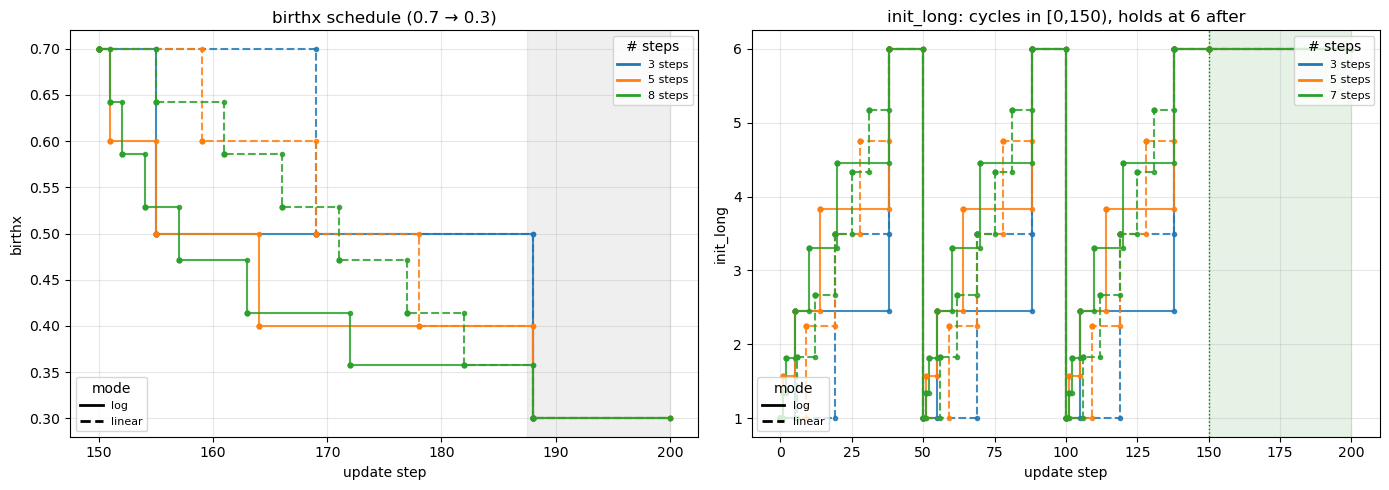

saved noisy_curriculum_step_modes.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Config constants ----
BIRTHX_START_T, BIRTHX_END_T = 150, 200
BIRTHX_HI, BIRTHX_LO = 0.7, 0.3
INIT_LONG_MIN, INIT_LONG_MAX = 1.0, 6.0
CYCLE_LEN = 50
INIT_CYCLE_END_T = 150          # cycling stops here; hold at MAX afterward
TOTAL_UPDATES = 200
HOLD_FRAC = 0.25

birthx_step_grid = [3, 5, 8]
init_step_grid = [3, 5, 7]


def _onsets(n_steps, span, mode):
    ramp_span = span * (1.0 - HOLD_FRAC)
    if mode == "linear":
        return np.linspace(0, ramp_span, n_steps, endpoint=True)
    return np.geomspace(1, ramp_span + 1, n_steps) - 1


def make_init_schedule(n_steps, mode):
    """init_long cycles (refresh every CYCLE_LEN) only during [0, INIT_CYCLE_END_T),
    then pins at MAX (6) from INIT_CYCLE_END_T to the end of training."""
    offs = _onsets(n_steps, CYCLE_LEN, mode)
    vals = (np.geomspace(INIT_LONG_MIN, INIT_LONG_MAX, n_steps) if mode == "log"
            else np.linspace(INIT_LONG_MIN, INIT_LONG_MAX, n_steps))
    sched = {}
    n_cycles = INIT_CYCLE_END_T // CYCLE_LEN
    for c in range(n_cycles):
        base = c * CYCLE_LEN
        for off, v in zip(offs, vals):
            sched[int(round(base + off))] = round(float(v), 4)
    # pin at MAX once cycling ends, and train at it for the rest of the run
    sched[INIT_CYCLE_END_T] = float(INIT_LONG_MAX)
    return sched


def step_trace(ts, vals, t_end):
    xs, ys = [], []
    for i, (t, v) in enumerate(zip(ts, vals)):
        nxt = ts[i + 1] if i + 1 < len(ts) else t_end
        xs.extend([t, nxt]); ys.extend([v, v])
    return xs, ys


MODE_STYLE = {"log": "-", "linear": "--"}
cmap = plt.get_cmap("tab10")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- birthx (unchanged) ---
ax = axes[0]
birthx_colors = {n: cmap(i) for i, n in enumerate(birthx_step_grid)}
span = BIRTHX_END_T - BIRTHX_START_T
for n in birthx_step_grid:
    c = birthx_colors[n]
    vals = np.linspace(BIRTHX_HI, BIRTHX_LO, n)
    for mode, ls in MODE_STYLE.items():
        ts = np.round(BIRTHX_START_T + _onsets(n, span, mode)).astype(int)
        xs, ys = step_trace(ts, vals, BIRTHX_END_T)
        ax.plot(xs, ys, ls, color=c, marker="o", ms=3, alpha=0.85)
        ax.scatter(ts, vals, s=12, color=c, zorder=5)
ax.axvspan(BIRTHX_START_T + span * (1 - HOLD_FRAC), BIRTHX_END_T,
           color="gray", alpha=0.12)
ax.set_title("birthx schedule (0.7 → 0.3)")
ax.set_xlabel("update step"); ax.set_ylabel("birthx"); ax.grid(alpha=0.3)

# --- init_long: full timeline now, cycles then holds at 6 ---
ax = axes[1]
init_colors = {n: cmap(i) for i, n in enumerate(init_step_grid)}
for n in init_step_grid:
    c = init_colors[n]
    for mode, ls in MODE_STYLE.items():
        sched = make_init_schedule(n, mode)
        ts = np.array(sorted(sched))
        vals = np.array([sched[t] for t in ts])
        xs, ys = step_trace(ts, vals, TOTAL_UPDATES)
        ax.plot(xs, ys, ls, color=c, marker="o", ms=3, alpha=0.85)
        ax.scatter(ts, vals, s=12, color=c, zorder=5)
ax.axvspan(INIT_CYCLE_END_T, TOTAL_UPDATES, color="green", alpha=0.10)
ax.axvline(INIT_CYCLE_END_T, color="green", ls=":", lw=1)
ax.set_title("init_long: cycles in [0,150), holds at 6 after")
ax.set_xlabel("update step"); ax.set_ylabel("init_long"); ax.grid(alpha=0.3)

from matplotlib.lines import Line2D
for ax, colors, grid in [(axes[0], birthx_colors, birthx_step_grid),
                         (axes[1], init_colors, init_step_grid)]:
    color_handles = [Line2D([0], [0], color=colors[n], lw=2, label=f"{n} steps")
                     for n in grid]
    style_handles = [Line2D([0], [0], color="k", lw=2, ls=ls, label=mode)
                     for mode, ls in MODE_STYLE.items()]
    leg1 = ax.legend(handles=color_handles, fontsize=8, loc="upper right", title="# steps")
    ax.add_artist(leg1)
    ax.legend(handles=style_handles, fontsize=8, loc="lower left", title="mode")

plt.tight_layout()
plt.savefig("noisy_curriculum_step_modes.png", dpi=130)
plt.show()
print("saved noisy_curriculum_step_modes.png")

# now_init_long sweep - gen (noisy)

In [3]:
import json
import numpy as np
from itertools import product
from pathlib import Path

DATASET = "noisy_jitterx5b5"
short_hand = "noisy"
# ---- Grid definition ----
birthx_step_grid = [3, 5, 8]
init_step_grid = [3, 5, 7]
birthx_mode_grid = ["linear", "log"]
init_mode_grid = ["linear"]                 # only linear for init_long for now


# ---- Fixed reference values from the original curriculum ----
BIRTHX_START_T, BIRTHX_END_T = 150, 200     # birthx active window
BIRTHX_HI, BIRTHX_LO = 0.7, 0.3             # value at start -> final value

INIT_LONG_MIN, INIT_LONG_MAX = 1.0, 6.0     # init_long ramps within each cycle
CYCLE_LEN = 50                              # restart_period; FIXED
INIT_CYCLE_END_T = 150                      # cycling stops here; hold at MAX after
TOTAL_UPDATES = 200
RESTART_PERIOD = 50

HOLD_FRAC = 0.25                            # trailing hold so agent trains at final value

WIND_COND = {"0": 1}
ROTATE_BY = {
    "0":   [0, 180],
    "50":  [90, -90],
    "100": [0, 90, 180, -90],
}


def _onsets(n_steps, span, mode):
    """Onsets within the ramp portion (window minus trailing hold). Last onset
    lands at ramp_span so the final value persists through the hold interval."""
    ramp_span = span * (1.0 - HOLD_FRAC)
    if mode == "linear":
        return np.linspace(0, ramp_span, n_steps, endpoint=True)
    elif mode == "log":
        return np.geomspace(1, ramp_span + 1, n_steps) - 1
    raise ValueError(mode)


def make_birthx_schedule(n_steps, mode):
    """birthx steps HI -> LO over [150, 200], reserving a trailing hold so the
    agent trains at the final value."""
    span = BIRTHX_END_T - BIRTHX_START_T
    offsets = _onsets(n_steps, span, mode)
    vals = np.linspace(BIRTHX_HI, BIRTHX_LO, n_steps)

    sched = {}
    for off, v in zip(offsets, vals):
        sched[str(int(round(BIRTHX_START_T + off)))] = round(float(v), 4)
    return sched


def make_init_schedule(n_steps, mode):
    """init_long cycles (refresh every CYCLE_LEN) during [0, INIT_CYCLE_END_T),
    then pins at MAX (6) from INIT_CYCLE_END_T through the end of training."""
    offsets = _onsets(n_steps, CYCLE_LEN, mode)
    if mode == "linear":
        vals = np.linspace(INIT_LONG_MIN, INIT_LONG_MAX, n_steps)
    else:
        vals = np.geomspace(INIT_LONG_MIN, INIT_LONG_MAX, n_steps)

    sched = {}
    n_cycles = INIT_CYCLE_END_T // CYCLE_LEN
    for c in range(n_cycles):
        base = c * CYCLE_LEN
        for off, v in zip(offsets, vals):
            sched[str(int(round(base + off)))] = round(float(v), 4)
    # pin at MAX once cycling ends; holds flat for the rest of the run
    sched[str(INIT_CYCLE_END_T)] = float(INIT_LONG_MAX)
    return sched


def build_config(birthx_steps, birthx_mode, init_steps, init_mode):
    return {
        "birthx": make_birthx_schedule(birthx_steps, birthx_mode),
        "wind_cond": WIND_COND,
        f"{DATASET}_rotate_by": ROTATE_BY,
        f"{DATASET}_now_init_long": make_init_schedule(init_steps, init_mode),
        "meta": {
            "restart_period": RESTART_PERIOD,
            "total_num_updates": TOTAL_UPDATES,
        },
    }


out_dir = Path("/gscratch/portia/jqhu/work/active_sensing/smartFlies/tamagotchi/conf/curriculum/")
out_dir.mkdir(exist_ok=True)

count = 0
for bx_steps, bx_mode, il_steps, il_mode in product(
    birthx_step_grid, birthx_mode_grid, init_step_grid, init_mode_grid
):
    cfg = build_config(bx_steps, bx_mode, il_steps, il_mode)
    name = f"sweep_{short_hand}_bx{bx_steps}-{bx_mode}_il{il_steps}-{il_mode}.json"
    with open(out_dir / name, "w") as f:
        json.dump(cfg, f, indent=2)
    count += 1

print(f"Generated {count} configs in {out_dir}/")

Generated 18 configs in /gscratch/portia/jqhu/work/active_sensing/smartFlies/tamagotchi/conf/curriculum/
